In [ ]:
%load_ext autoreload
%autoreload 2

import logging
import re
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from ppcluster import load_config, setup_logger

logger = setup_logger(logging.INFO, name="ppcx")

input_dir = Path("output")
output_dir = input_dir / "kinematic_sectors_time_series"

config = load_config()

if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

output_dir.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def find_result_folders(
    base_dir: Path,
    pattern: str = r".*_\d{4}-\d{2}-\d{2}$",
):
    """
    Find all result folders matching the pattern.

    Args:
        base_dir: Base directory to search
        pattern: Regex pattern for folder names (default matches CAMERA_YYYY-MM-DD)

    Returns:
        List of (date, folder_path) tuples sorted by date
    """
    folders = []
    date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

    for folder in base_dir.iterdir():
        if not folder.is_dir():
            continue
        if re.match(pattern, folder.name):
            # Extract date from folder name
            match = date_pattern.search(folder.name)
            if match:
                date_str = match.group(1)
                folders.append((date_str, folder))

    # Sort by date
    folders.sort(key=lambda x: x[0])

    # Return only folder paths
    folders = [folder for _, folder in folders]

    return folders


def load_sector_results(folder: Path, search_pattern: str | None = None):
    """
    Load sector results from a single date folder.

    Args:
        folder: Path to result folder
        search_pattern: Optional search pattern for bundle files (auto-detected if None)

    Returns:
        Dictionary with sector data or None if loading fails
    """
    try:
        # Auto-detect base_name from folder if not provided
        if search_pattern is None:
            search_pattern = "*results.joblib"

        # Look for the bundle file
        bundle_files = list(folder.glob(search_pattern))
        if not bundle_files:
            raise FileNotFoundError(f"No bundle file found in {folder}")

        if len(bundle_files) > 1:
            logger.warning(
                f"Multiple bundle files found in {folder}, using the first one"
            )
        bundle_path = bundle_files[0]

        # Load main results bundle
        if not bundle_path.exists():
            raise FileNotFoundError(f"Bundle file not found: {bundle_path}")

        bundle = joblib.load(bundle_path)
        if not isinstance(bundle, dict):
            raise ValueError(f"Invalid bundle format in {bundle_path}")

        # Extract relevant data
        date = bundle.get("reference_date", None)
        sectors = bundle.get("sectors", None)
        sector_stats = bundle.get("sector_stats", None)
        pts_by_sector = bundle.get("pts_by_sector", None)

        return {
            "date": date,
            "sectors": sectors,
            "stats": sector_stats,
            "pts_by_sector": pts_by_sector,
        }

    except Exception as exc:
        logger.error(f"Failed to load results from {folder}: {exc}")
        return None


def collect_statistics(results_list):
    # Collect data for each sector
    dates = []
    sector_data = {}

    for result in results_list:
        if result is None:
            continue

        date = result["date"]
        dates.append(date)
        stats = result["stats"]

        for _, row in stats.iterrows():
            sector = row["sector"]
            if sector not in sector_data:
                sector_data[sector] = {
                    "v_mean": [],
                    "v_std": [],
                    "v_median": [],
                    "v_mad": [],
                    "n_points": [],
                    "area_px2": [],
                }

            sector_data[sector]["v_mean"].append(row.get("v_mean", np.nan))
            sector_data[sector]["v_std"].append(row.get("v_std", np.nan))
            sector_data[sector]["v_median"].append(row.get("v_median", np.nan))
            sector_data[sector]["v_mad"].append(row.get("v_mad", np.nan))
            sector_data[sector]["n_points"].append(row.get("n_points", 0))
            sector_data[sector]["area_px2"].append(row.get("area_px2", 0))

    if not dates:
        logger.warning("No valid dates found for time series")
        # return

    dates_dt = pd.to_datetime(dates)

    return dates_dt, sector_data

In [ ]:
dir_pattern = r".*_\d{4}-\d{2}-\d{2}$"
results_pattern = "*results.joblib"

# Find result folders
logger.info(f"Searching for result folders in {input_dir}...")
folders = find_result_folders(input_dir, pattern=dir_pattern)
logger.info(f"Found {len(folders)} result folders")

# Load results from all dates
logger.info("Loading results from all dates...")
results_list = []
for folder in folders:
    result = load_sector_results(folder, search_pattern=results_pattern)
    if result is not None:
        results_list.append(result)
logger.info(f"Successfully loaded {len(results_list)} / {len(folders)} results")

dates_dt, sector_data = collect_statistics(results_list)

2026-01-21 14:50:26 | [INFO    ] Searching for result folders in output...
2026-01-21 14:50:26 | [INFO    ] Found 152 result folders


2026-01-21 14:50:26 | [INFO    ] Loading results from all dates...
2026-01-21 14:50:27 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-08: No bundle file found in output/PPCX_Tele_2020-06-08
2026-01-21 14:50:27 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-09: No bundle file found in output/PPCX_Tele_2020-06-09
2026-01-21 14:50:27 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-10: No bundle file found in output/PPCX_Tele_2020-06-10
2026-01-21 14:50:27 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-12: No bundle file found in output/PPCX_Tele_2020-06-12
2026-01-21 14:50:27 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-13: No bundle file found in output/PPCX_Tele_2020-06-13
2026-01-21 14:50:27 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-09-20: No bundle file found in output/PPCX_Tele_2020-09-20
2026-01-21 14:50:27 | [ERROR   ] Failed to load results from output/PPCX_Tele_202

2026-01-21 14:55:33 | [INFO    ] Saved velocity time series to output/kinematic_sectors_time_series/sectors_velocity_time_series.png


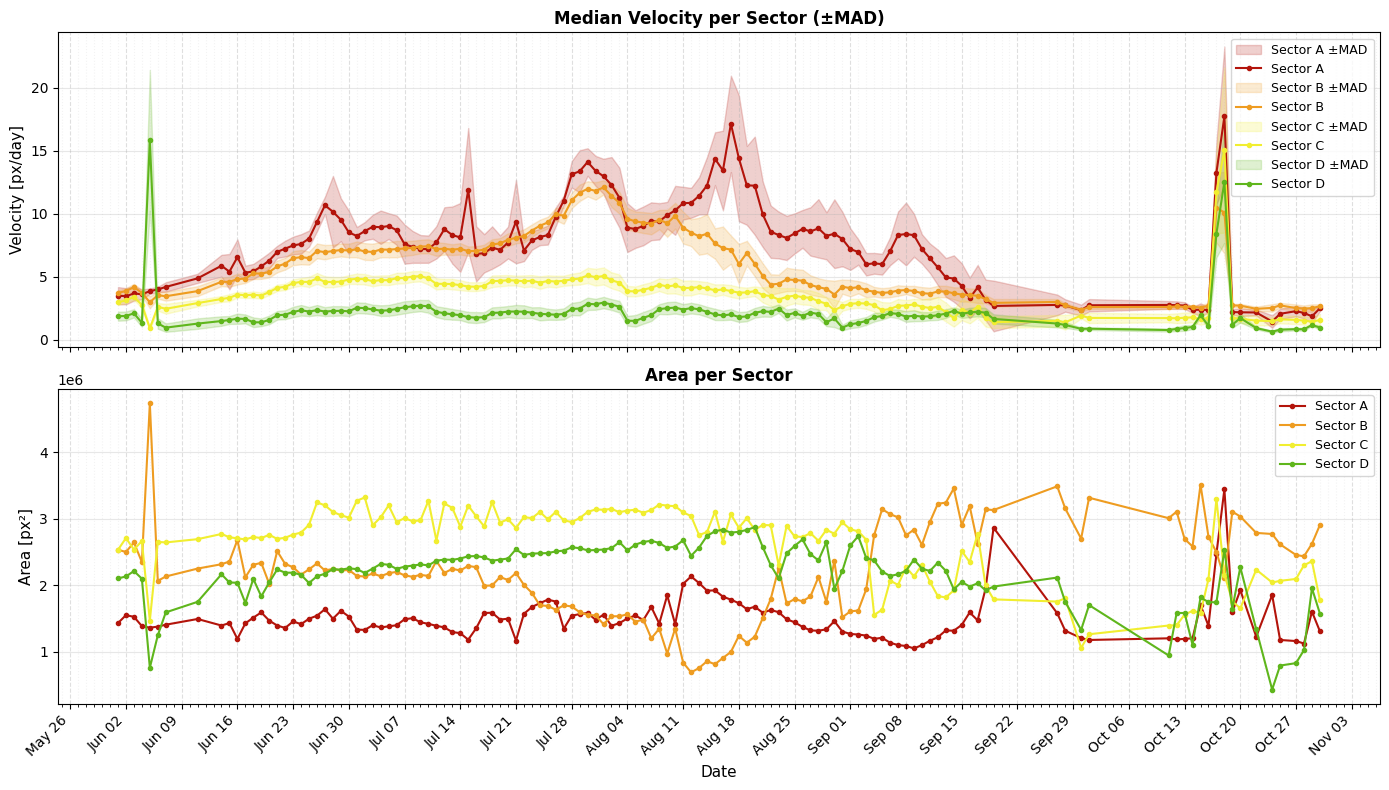

In [17]:
# Create figure with time series of velocity and area of each sector (in different subplots)

output_path = output_dir / "sectors_velocity_time_series.png"

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Get colormap
colors = config.postprocessing.sector_assignment.get("sector_colors", {})
if not colors:
    # Use default colormap if no colors are specified
    cmap = plt.get_cmap("tab10")
    colors = {
        sector: cmap(i % cmap.N) for i, sector in enumerate(sorted(sector_data.keys()))
    }

# Plot 1: Median velocity with MAD error bands
ax1 = axes[0]
for sector in sorted(sector_data.keys()):
    data = sector_data[sector]
    v_median = np.array(data["v_median"])
    v_mad = np.array(data["v_mad"])
    ax1.fill_between(
        dates_dt,
        v_median - v_mad,
        v_median + v_mad,
        color=colors[sector],
        alpha=0.2,
        label=f"Sector {sector} ±MAD",
    )
    ax1.plot(
        dates_dt,
        v_median,
        marker="o",
        markersize=3,
        linestyle="-",
        linewidth=1.5,
        label=f"Sector {sector}",
        color=colors[sector],
    )
ax1.set_ylabel("Velocity [px/day]", fontsize=11)
ax1.set_title("Median Velocity per Sector (±MAD)", fontsize=12, weight="bold")
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Area of each sector over time
ax2 = axes[1]
for sector in sorted(sector_data.keys()):
    data = sector_data[sector]
    area_px2 = np.array(data["area_px2"])
    ax2.plot(
        dates_dt,
        area_px2,
        marker="o",
        markersize=3,
        linestyle="-",
        linewidth=1.5,
        label=f"Sector {sector}",
        color=colors[sector],
    )

ax2.set_xlabel("Date", fontsize=11)
ax2.set_ylabel("Area [px²]", fontsize=11)
ax2.set_title("Area per Sector", fontsize=12, weight="bold")
ax2.legend(loc="best", fontsize=9)
ax2.grid(True, alpha=0.3)

# Set ticks for shared-x axes
major_locator = mdates.WeekdayLocator(interval=1)  # weekly ticks
# major_locator = mdates.AutoDateLocator(minticks=8, maxticks=20)  # auto ticks
major_formatter = mdates.DateFormatter("%b %d")  # or "%b %d" for compact labels
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_minor_locator(mdates.DayLocator())  # dayily minor ticks
    ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)
fig.autofmt_xdate(rotation=45, ha="right")  # rotate labels to avoid overlap

plt.tight_layout()

fig.savefig(output_path, dpi=300, bbox_inches="tight")
fig.savefig(output_path.with_suffix(".svg"), dpi=300, bbox_inches="tight")
logger.info(f"Saved velocity time series to {output_path}")

In [ ]:
# # Collect data for each sector
# dates = []
# sector_data = {}

# for result in results_list:
#     if result is None:
#         continue

#     date = result["date"]
#     dates.append(date)
#     stats = result["stats"]

#     for _, row in stats.iterrows():
#         sector = row["label"]
#         if sector not in sector_data:
#             sector_data[sector] = {
#                 "v_median": [],
#                 "v_mad": [],
#                 "v_mean": [],
#                 "v_std": [],
#                 "n_points": [],
#                 "area_px2": [],
#             }

#         sector_data[sector]["v_median"].append(row.get("v_median", np.nan))
#         sector_data[sector]["v_mad"].append(row.get("v_mad", np.nan))
#         sector_data[sector]["v_mean"].append(row.get("v_mean", np.nan))
#         sector_data[sector]["v_std"].append(row.get("v_std", np.nan))
#         sector_data[sector]["n_points"].append(row.get("n_points", 0))
#         sector_data[sector]["area_px2"].append(row.get("area_px2", 0))

# if not dates:
#     logger.warning("No valid dates found for time series")
#     return

# dates_dt = pd.to_datetime(dates)

# # Combined plot velocity-area for each sector separately
# fig, axes = plt.subplots(4, 1, figsize=(14, 8))
# for ax, sector in zip(axes, sorted(sector_data.keys()), strict=False):
#     data = sector_data[sector]
#     v_median = np.array(data["v_median"])
#     v_mad = np.array(data["v_mad"])
#     area = np.array(data["area_px2"])
#     norm = Normalize(vmin=np.min(area), vmax=np.max(area))
#     color = cm.get_cmap("Reds")
#     colors_area = color(norm(area))
#     ax.errorbar(
#         dates_dt,
#         v_median,
#         yerr=v_mad,
#         markersize=0,
#         linestyle="-",
#         linewidth=0.5,
#         label=f"Sector {sector}",
#         color="k",
#         alpha=0.7,
#     )
#     ax.scatter(
#         dates_dt,
#         v_median,
#         s=70,
#         c=colors_area,
#         label="Area (px²)",
#         edgecolors="k",
#         zorder=3,
#     )
#     ax.set_ylabel("Velocity [px/day]", fontsize=11)
#     ax.set_title(
#         f"Sector {sector}: Median Velocity with Area Indication",
#         fontsize=12,
#         weight="bold",
#     )
#     ax.legend(loc="best", fontsize=9)
#     ax.grid(True, alpha=0.3)

#     # force y-limits for better comparison
#     ax.set_ylim([0, 20])

# fig.tight_layout()
# fig.savefig(
#     output_path.parent / "velocity_area_time_series.png",
#     dpi=200,
#     bbox_inches="tight",
# )
# plt.close(fig)

KeyError: 'label'

In [ ]:
# def ____create_velocity_time_series(
#     results_list: list,
#     output_path: Path,
#     config,
# ):
#     """
#     Create time series plots of velocity statistics per sector.

#     Args:
#         results_list: List of result dictionaries from load_sector_results
#         output_path: Path to save the figure
#         config: DictConfig instance with configuration
#     """
#     # Collect data for each sector
#     dates = []
#     sector_data = {}

#     for result in results_list:
#         if result is None:
#             continue

#         date = result["date"]
#         dates.append(date)
#         stats = result["stats"]

#         for _, row in stats.iterrows():
#             sector = row["label"]
#             if sector not in sector_data:
#                 sector_data[sector] = {
#                     "v_median": [],
#                     "v_mad": [],
#                     "v_mean": [],
#                     "v_std": [],
#                     "n_points": [],
#                     "area_px2": [],
#                 }

#             sector_data[sector]["v_median"].append(row.get("v_median", np.nan))
#             sector_data[sector]["v_mad"].append(row.get("v_mad", np.nan))
#             sector_data[sector]["v_mean"].append(row.get("v_mean", np.nan))
#             sector_data[sector]["v_std"].append(row.get("v_std", np.nan))
#             sector_data[sector]["n_points"].append(row.get("n_points", 0))
#             sector_data[sector]["area_px2"].append(row.get("area_px2", 0))

#     if not dates:
#         logger.warning("No valid dates found for time series")
#         return

#     dates_dt = pd.to_datetime(dates)

#     # Combined plot velocity-area for each sector separately
#     fig, axes = plt.subplots(4, 1, figsize=(14, 8))
#     for ax, sector in zip(axes, sorted(sector_data.keys()), strict=False):
#         data = sector_data[sector]
#         v_median = np.array(data["v_median"])
#         v_mad = np.array(data["v_mad"])
#         area = np.array(data["area_px2"])
#         norm = Normalize(vmin=np.min(area), vmax=np.max(area))
#         color = cm.get_cmap("Reds")
#         colors_area = color(norm(area))
#         ax.errorbar(
#             dates_dt,
#             v_median,
#             yerr=v_mad,
#             markersize=0,
#             linestyle="-",
#             linewidth=0.5,
#             label=f"Sector {sector}",
#             color="k",
#             alpha=0.7,
#         )
#         ax.scatter(
#             dates_dt,
#             v_median,
#             s=70,
#             c=colors_area,
#             label="Area (px²)",
#             edgecolors="k",
#             zorder=3,
#         )
#         ax.set_ylabel("Velocity [px/day]", fontsize=11)
#         ax.set_title(
#             f"Sector {sector}: Median Velocity with Area Indication",
#             fontsize=12,
#             weight="bold",
#         )
#         ax.legend(loc="best", fontsize=9)
#         ax.grid(True, alpha=0.3)

#         # force y-limits for better comparison
#         ax.set_ylim([0, 20])

#     fig.tight_layout()
#     fig.savefig(
#         output_path.parent / "velocity_area_time_series.png",
#         dpi=200,
#         bbox_inches="tight",
#     )
#     plt.close(fig)


# def create_sectors_evolution_figure(
#     results_list: list,
#     output_path: Path,
#     config: DictConfig,
#     max_dates: int = 12,
#     ncols: int = 4,
# ):
#     """
#     Create multi-panel figure showing sector evolution over time.

#     Args:
#         results_list: List of result dictionaries
#         output_path: Path to save the figure
#         config: DictConfig instance for loading images
#         max_dates: Maximum number of dates to show
#         ncols: Number of columns in the subplot grid
#     """
#     # Limit to max_dates
#     if len(results_list) > max_dates:
#         step = len(results_list) // max_dates
#         results_list = results_list[::step][:max_dates]

#     n_dates = len(results_list)
#     nrows = int(np.ceil(n_dates / ncols))

#     fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
#     if n_dates == 1:
#         axes = np.array([axes])
#     axes = axes.flatten()

#     # Get consistent colors for sectors
#     all_sectors = set()
#     for result in results_list:
#         if result and result["stats"] is not None:
#             all_sectors.update(result["stats"]["label"].values)

#     cmap = plt.get_cmap("tab10")
#     colors = {sector: cmap(i % cmap.N) for i, sector in enumerate(sorted(all_sectors))}

#     for idx, result in enumerate(results_list):
#         ax = axes[idx]

#         if result is None:
#             ax.axis("off")
#             continue

#         # Load image
#         try:
#             if config:
#                 img = None
#             else:
#                 img = None

#             if img is not None:
#                 ax.imshow(img, alpha=0.5, cmap="gray")
#         except Exception:
#             pass

#         # Draw sector polygons
#         sector_polygons = result["sector_polygons"]
#         legend_patches = {}

#         for sector in sorted(sector_polygons.keys()):
#             coords = sector_polygons[sector]
#             if coords is None:
#                 continue

#             color = colors.get(sector, "#888888")
#             draw_polygon(ax, coords, color, fill_alpha=0.2, zorder=1)
#             legend_patches[sector] = mpatches.Patch(
#                 color=color, label=f"{sector}", alpha=0.5
#             )

#         # Add legend only to first subplot
#         if idx == 0 and legend_patches:
#             ax.legend(
#                 handles=list(legend_patches.values()),
#                 labels=list(legend_patches.keys()),
#                 loc="upper right",
#                 fontsize=7,
#                 framealpha=0.9,
#             )

#         ax.set_aspect("equal")
#         ax.set_xticks([])
#         ax.set_yticks([])
#         ax.set_title(result["date"], fontsize=9)

#     # Hide unused subplots
#     for idx in range(n_dates, len(axes)):
#         axes[idx].axis("off")

#     plt.suptitle(
#         "Morpho-Kinematic Sectors Evolution", fontsize=14, weight="bold", y=0.995
#     )
#     plt.tight_layout()
#     fig.savefig(output_path, dpi=150, bbox_inches="tight")
#     plt.close(fig)
#     logger.info(f"Saved sectors evolution figure to {output_path}")
